In [1]:
from datasets import load_dataset

MultiD = load_dataset("IVLLab/MultiDialog", "valid_freq",
                       trust_remote_code=True)

# see structure
print(MultiD)

# load audio sample on the fly
audio_input = MultiD["valid_freq"][0]["audio"]  # first decoded audio sample
transcription = MultiD["valid_freq"][0]["value"]  # first transcription



/home/siyuanch/ssd/local/anaconda3/envs/speech-agent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    valid_freq: Dataset({
        features: ['file_name', 'conv_id', 'utterance_id', 'audio', 'from', 'value', 'emotion', 'original_full_path'],
        num_rows: 8513
    })
})


In [2]:
import matplotlib.pyplot as plt

In [9]:
MultiD["valid_freq"][0]

{'file_name': 't_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29/t_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29_0e.wav',
 'conv_id': 't_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29',
 'utterance_id': 0.0,
 'audio': {'path': '/home/siyuanch/.cache/huggingface/datasets/downloads/extracted/8bf15eca812542f5b02ecfc687201a47e2b0132452d31bd8c5f6dcea4eda79fc/t_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29/t_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29_0e.wav',
  'array': array([ 3.41796875e-03,  4.30297852e-03,  4.33349609e-03, ...,
         -6.10351562e-05, -6.10351562e-05, -3.05175781e-05], shape=(89088,)),
  'sampling_rate': 16000},
 'from': 'human',
 'value': 'Did you know that the average NFL game only had 11 minutes of live gameplay?',
 'emotion': 'Surprised',
 'original_full_path': 'valid_freq/t_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29/t_d467e3c6-0421-4d4e-b4bb-2d8901cdfa29_0e.wav'}

In [3]:
from collections import Counter
counts = Counter(MultiD["valid_freq"]['conv_id'])


(array([ 58.,   0.,   0.,   0.,   0., 255., 118.,  15.,   1.,   1.]),
 array([ 1. ,  4.4,  7.8, 11.2, 14.6, 18. , 21.4, 24.8, 28.2, 31.6, 35. ]),
 <BarContainer object of 10 artists>)

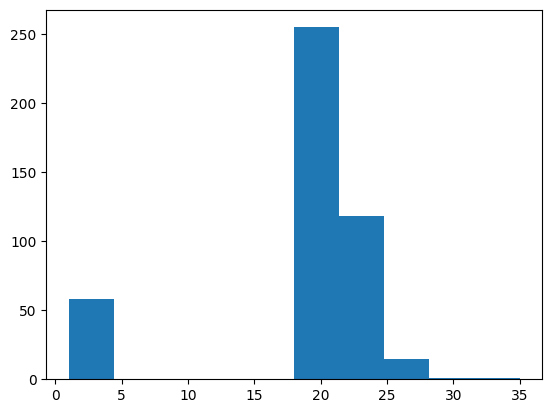

In [4]:
plt.hist(counts.values())

In [5]:
dataset = MultiD['valid_freq']
conv_ids = set()
for i in range(len(dataset)):
    if dataset[i]['from'] == 'gpt':
        conv_ids.add(dataset[i]['conv_id'])
len(conv_ids)

397

In [7]:
a = dataset[0]['audio']['array']
type(a)

numpy.ndarray

In [5]:
gpt_dataset = dataset.filter(lambda x: x['conv_id'] in conv_ids)
gpt_dataset

Dataset({
    features: ['file_name', 'conv_id', 'utterance_id', 'audio', 'from', 'value', 'emotion', 'original_full_path'],
    num_rows: 8462
})

In [6]:
df = dataset.to_pandas()

In [42]:
lengths_ds = gpt_dataset.map(
    lambda x: {
        "duration_sec": x["audio"]["array"].size / x["audio"]["sampling_rate"]
    }
)

Map: 100%|██████████| 8462/8462 [09:16<00:00, 15.19 examples/s] 


In [54]:
df = lengths_ds.to_pandas()

In [55]:
df.columns

Index(['file_name', 'conv_id', 'utterance_id', 'audio', 'from', 'value',
       'emotion', 'original_full_path', 'duration_sec'],
      dtype='object')

In [56]:
import tiktoken 
tokenizer = tiktoken.encoding_for_model("gpt-5")
df['n_tokens'] = [len(x) for x in tokenizer.encode_batch(df['value'])]

In [57]:
df[df['from'] == 'human']['n_tokens'].describe()

count    4377.000000
mean       22.713274
std        11.445315
min         1.000000
25%        14.000000
50%        21.000000
75%        29.000000
max        95.000000
Name: n_tokens, dtype: float64

In [58]:
df[df['from'] == 'gpt']['n_tokens'].describe()

count    4085.000000
mean       24.752509
std        12.282414
min         1.000000
25%        16.000000
50%        23.000000
75%        31.000000
max        87.000000
Name: n_tokens, dtype: float64

In [59]:
df.groupby('conv_id')['n_tokens'].sum().describe()

count     397.000000
mean      505.113350
std       148.899667
min        18.000000
25%       418.000000
50%       504.000000
75%       594.000000
max      1240.000000
Name: n_tokens, dtype: float64

In [60]:
df.groupby('conv_id').size().describe()

count    397.000000
mean      21.314861
std        2.892712
min        2.000000
25%       21.000000
50%       21.000000
75%       22.000000
max       35.000000
dtype: float64

In [61]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

In [62]:
def fit_and_plot(x):
    # scipy parameterization: n (r), p
    # Use MLE via scipy
    mu = x.mean()
    var = x.var(ddof=1)

    alpha = max((var - mu) / (mu**2), 1e-8)
    r = 1 / alpha
    p = r / (r + mu)

    xs = np.arange(0, x.max()+1)
    plt.hist(x, bins=40, density=True, alpha=0.4, label="data")
    plt.plot(xs, stats.nbinom.pmf(xs, r, p), label="NegBin fit")
    plt.legend()
    plt.show()

    print(f"NB params: r={r:.2f}, p={p:.4f}")

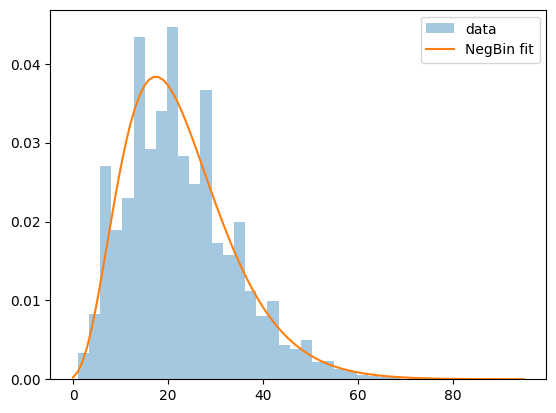

NB params: r=4.76, p=0.1734


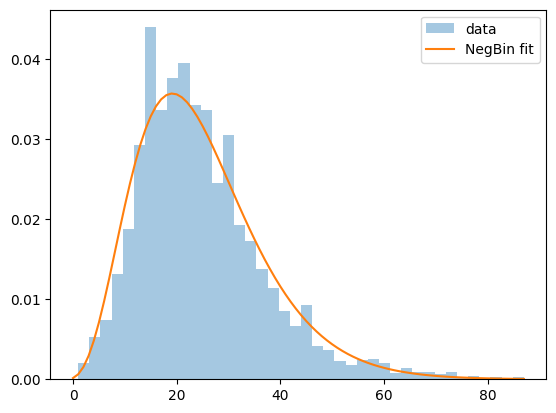

NB params: r=4.86, p=0.1641


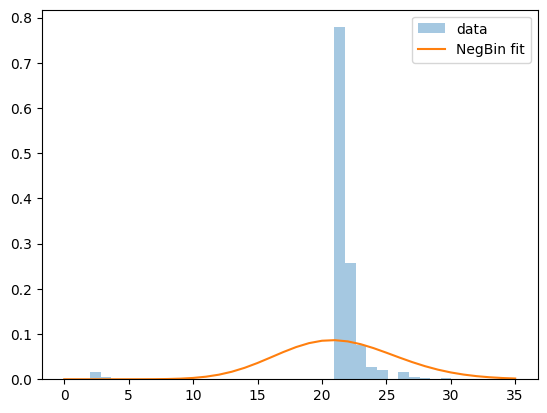

NB params: r=100000000.00, p=1.0000


(None, None, None)

In [63]:
human_tokens = df[df['from'] == 'human']['n_tokens']
gpt_tokens = df[df['from'] == 'gpt']['n_tokens']
n_rounds = df.groupby('conv_id').size()
fit_and_plot(human_tokens), fit_and_plot(gpt_tokens), fit_and_plot(n_rounds)

In [64]:

lengths = df.groupby("conv_id").size().astype(int).values
N = lengths.max()          # likely 21
SHORT_MAX = 2              # tweak if you want (e.g., 3)

# --- fit mixture weight for "short" chats ---
short = lengths[lengths <= SHORT_MAX]
long_ = lengths[lengths > SHORT_MAX]

pi_short = len(short) / len(lengths)

# empirical distribution over short lengths (e.g. P(L=1), P(L=2))
vals = np.arange(1, SHORT_MAX + 1)
p_short = np.array([(short == v).mean() for v in vals])
p_short = p_short / p_short.sum()  # just in case

# --- fit geometric continuation prob q on the "long" chats, ignoring censored-at-N ones ---
# If N is a cap, treat L==N as censored; fit q using only L < N
uncensored_long = long_[long_ < N]

# geometric on {1,2,3,...} for "additional rounds after SHORT_MAX"
# We model T = L - SHORT_MAX, T>=1.
T = uncensored_long - SHORT_MAX
T = T[T >= 1]

# MLE for geometric continuation:
# For geometric with P(T=t)=(1-q)*q^(t-1), E[T]=1/(1-q) => q = 1 - 1/E[T]
q = 1.0 - 1.0 / max(T.mean(), 1.000001)

print(f"N (cap) = {N}")
print(f"pi_short = {pi_short:.3f}")
print(f"short support = {vals.tolist()}, p_short = {p_short}")
print(f"q (continue prob) = {q:.3f}")

# --- sampler ---
def sample_chat_rounds(n: int, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    out = np.empty(n, dtype=int)

    # decide short vs long
    is_short = rng.random(n) < pi_short

    # sample short
    out[is_short] = rng.choice(vals, size=is_short.sum(), p=p_short)

    # sample long: L = SHORT_MAX + geometric(T) capped at N
    m = (~is_short).sum()
    if m > 0:
        # sample geometric T with support {1,2,...}
        # numpy's geometric uses support {1,2,...} with parameter p_stop = (1-q)
        p_stop = 1.0 - q
        T_samp = rng.geometric(p_stop, size=m)
        L = SHORT_MAX + T_samp
        out[~is_short] = np.minimum(L, N)

    return out

N (cap) = 35
pi_short = 0.013
short support = [1, 2], p_short = [0. 1.]
q (continue prob) = 0.949


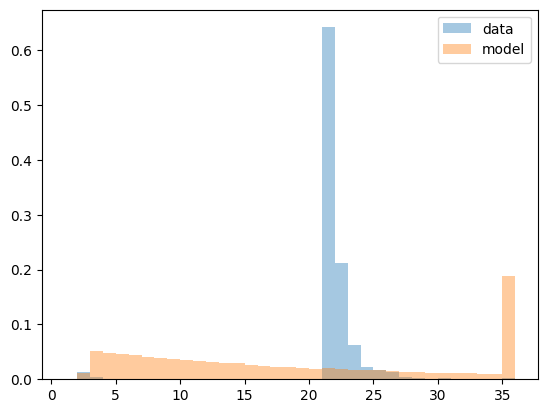

In [65]:
import matplotlib.pyplot as plt

samp = sample_chat_rounds(20000, seed=0)

plt.hist(lengths, bins=np.arange(1, N+2), density=True, alpha=0.4, label="data")
plt.hist(samp,    bins=np.arange(1, N+2), density=True, alpha=0.4, label="model")
plt.legend()
plt.show()

In [66]:
df.groupby('conv_id')['utterance_id'].max()

conv_id
t_004e2520-3e79-44bd-91a0-8fe9b26026fe    20.0
t_0081ed02-9b2e-419f-b962-eb7c54e29127    22.0
t_01b2127e-1c70-4918-93cb-5f23bce4ba72    20.0
t_022a9e43-bb8e-4452-9713-ebf456d6320e    20.0
t_02722a25-ceef-47a5-8cea-205186520f9e    21.0
                                          ... 
t_faee6df9-8e7b-45b4-8130-7696211c6afa    20.0
t_fbf56c5f-5552-46fb-af83-50a7d1975e2d    20.0
t_fc4aa9a5-4f18-491d-b311-1247165498db    21.0
t_fd34ecc7-d715-47e0-bec9-f1bca217bf06    20.0
t_ffa55df6-114d-4b36-87a1-7af6b8b63d9b    20.0
Name: utterance_id, Length: 397, dtype: float32

In [67]:
df['audio'].iloc[0]

{'bytes': b'RIFF$\xb8\x02\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00data\x00\xb8\x02\x00p\x00\x8d\x00\x8e\x00w\x00m\x00L\x00\x0e\x00\xa5\xff\x98\xff\x99\xff\xa1\xff\xd5\xff\xcf\xff\xbb\xff\xc3\xff\xad\xff\xa9\xff\xe7\xffS\x00\x92\x00\x9e\x00\xa5\x00\xaf\x00\xa2\x00\xae\x00\xcb\x00\xf2\x00\x0f\x01\x1c\x010\x016\x017\x01G\x01@\x01.\x016\x018\x01\xee\x00\xa7\x00\xb5\x00\xfb\x00H\x01\x7f\x01\x92\x01\x9c\x01V\x01\xea\x00\x8e\x00E\x00\x1c\x00*\x00F\x00W\x00f\x00[\x00-\x00\xdb\xff\x8b\xff\x0f\xff\x93\xfej\xfe\x90\xfe\xba\xfe\xec\xfeL\xff\x9a\xff|\xffq\xff}\xff\x9a\xffs\xffE\xffX\xff_\xff]\xffV\xff\x8e\xff\xc7\xff\xec\xff\x1c\x00V\x00\x88\x00\xd2\x00\x07\x01\x1e\x019\x01T\x01D\x01\'\x01"\x017\x015\x01\x07\x01\xe2\x00\xf0\x00\xec\x00\xd5\x00\xd3\x00\xf2\x00+\x01\x07\x01\xb0\x00i\x008\x00\xf4\xff\x90\xff@\xff\x19\xff\xfb\xfe"\xffM\xff\x8b\xff\xad\xff\xe0\xff`\xff\x95\xff\xba\xff\xb5\xfe\x87\xfe\x9f\xfe`\xfe+\xfe\xac\xfdx\xfed\xff\xbd\xff\xfd\xff_\xff\xc

<Axes: xlabel='n_tokens', ylabel='duration_sec'>

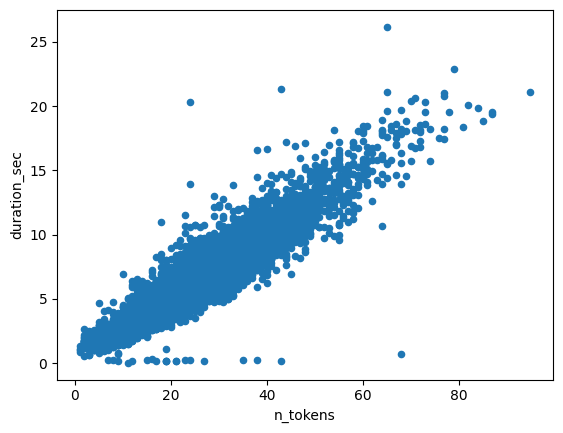

In [71]:
df.plot.scatter(x = 'n_tokens', y = 'duration_sec')

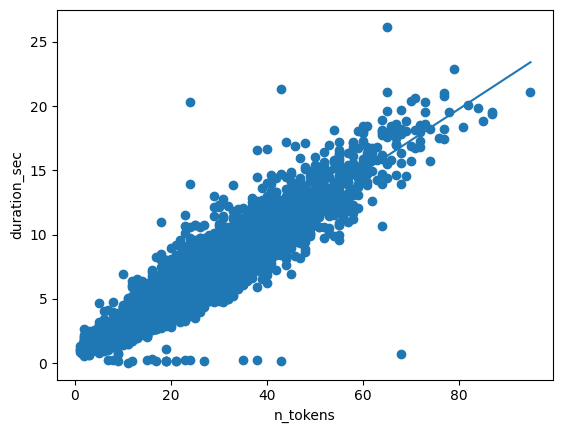

array([0.24391447, 0.24418946])

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Assume df is already defined in the environment
x = df['n_tokens'].to_numpy()
y = df['duration_sec'].to_numpy()

# Fit linear regression (least squares)
coef = np.polyfit(x, y, 1)
reg_line = np.poly1d(coef)

# Plot
plt.figure()
plt.scatter(x, y)
x_sorted = np.sort(x)
plt.plot(x_sorted, reg_line(x_sorted))
plt.xlabel("n_tokens")
plt.ylabel("duration_sec")
plt.show()
coef